In [37]:
print("helllo")


helllo


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)



In [39]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [40]:
iris = load_iris()
X = iris.data                      # shape: (150, 4)
y = iris.target                    # shape: (150,) -> values 0, 1, 2
feature_names = iris.feature_names
class_names = iris.target_names

In [41]:
df = pd.DataFrame(X, columns=feature_names)
df["species"] = pd.Categorical.from_codes(y, class_names)

print("Dataset shape:", X.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nClass distribution:\n", df["species"].value_counts())

Dataset shape: (150, 4)

First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Class distribution:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [44]:
num_classes = len(class_names)
y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_test_oh = keras.utils.to_categorical(y_test, num_classes)

In [45]:

print(f"\nTrain size: {X_train_scaled.shape[0]}, Test size: {X_test_scaled.shape[0]}")


Train size: 120, Test size: 30


In [46]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

In [47]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)


In [48]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 16)                80        
                                                                 
 dense_7 (Dense)             (None, 8)                 136       
                                                                 
 dense_8 (Dense)             (None, 3)                 27        
                                                                 
Total params: 243
Trainable params: 243
Non-trainable params: 0
_________________________________________________________________


In [49]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

In [50]:
history = model.fit(
    X_train_scaled, y_train_oh,
    validation_split=0.15,
    epochs=200,
    batch_size=8,
    callbacks=[early_stop],
    verbose=0,
)

In [51]:
print(f"\nTraining stopped after {len(history.history['loss'])} epochs.")


Training stopped after 186 epochs.


In [52]:
y_pred_probs = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

In [53]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)



Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


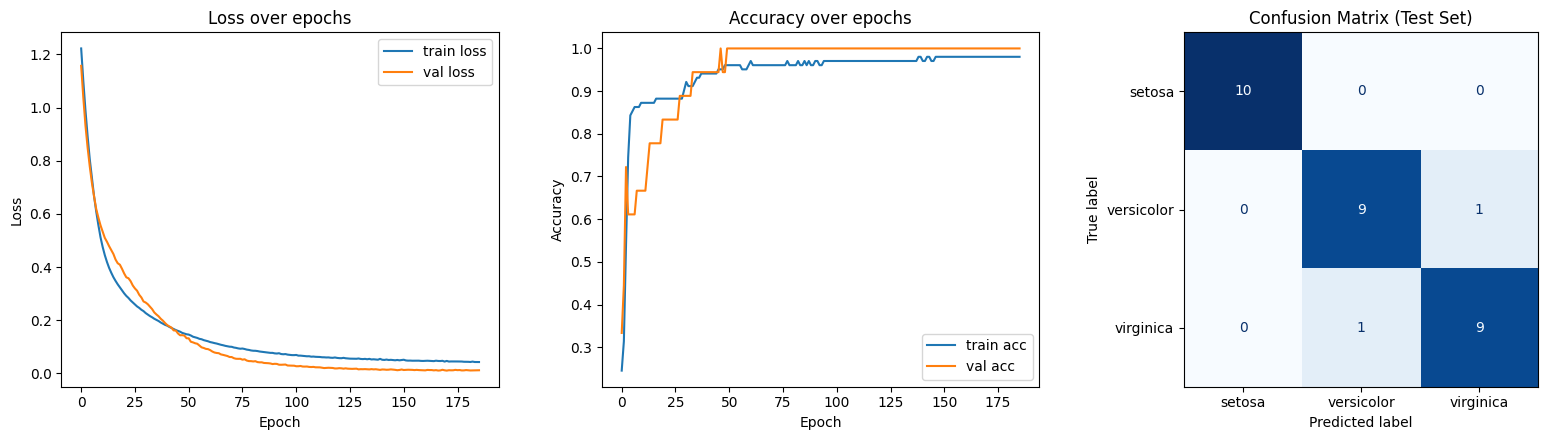

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train acc")
axes[1].plot(history.history["val_accuracy"], label="val acc")
axes[1].set_title("Accuracy over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[2], colorbar=False, cmap="Blues")
axes[2].set_title("Confusion Matrix (Test Set)")

plt.tight_layout()


In [55]:
sample = X_test_scaled[0:1]
pred_probs = model.predict(sample, verbose=0)[0]
pred_class = class_names[np.argmax(pred_probs)]
true_class = class_names[y_test[0]]

In [56]:

print(f"\nExample prediction -> Predicted: {pred_class}, Actual: {true_class}")
print("Class probabilities:", dict(zip(class_names, np.round(pred_probs, 3))))


Example prediction -> Predicted: setosa, Actual: setosa
Class probabilities: {'setosa': 1.0, 'versicolor': 0.0, 'virginica': 0.0}
